<a href="https://colab.research.google.com/github/Calum-Owen/ENPH_353_Lab_2/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports and setting up video


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video = cv2.VideoCapture("/content/raw_video_feed.mp4")

if video.isOpened():
  print("Opened")
else:
  print("Video not found")

Opened


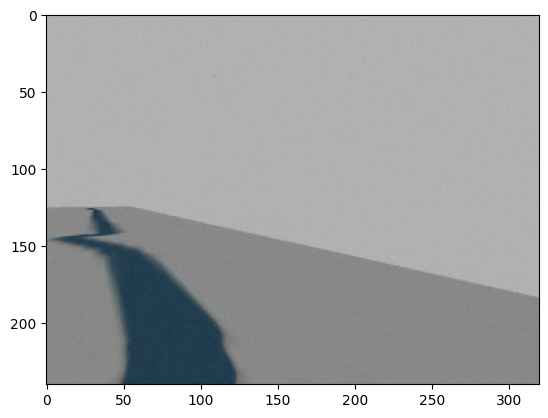

In [20]:
ret, frame = video.read()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)

Determining which signal is best and theresholds

In [21]:
blue, green, red = cv2.split(frame)

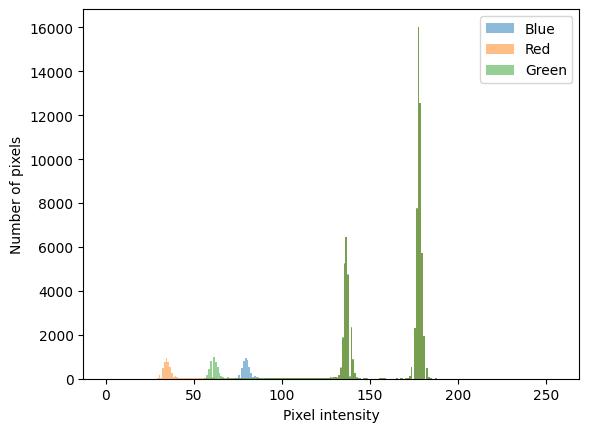

In [22]:
plt.hist(blue.ravel(), bins=256, range=(0, 256), alpha=0.5, label="Blue")
plt.hist(red.ravel(), bins=256, range=(0, 256), alpha=0.5, label="Red")
plt.hist(green.ravel(), bins=256, range=(0, 256), alpha=0.5, label="Green")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.legend()
plt.show()

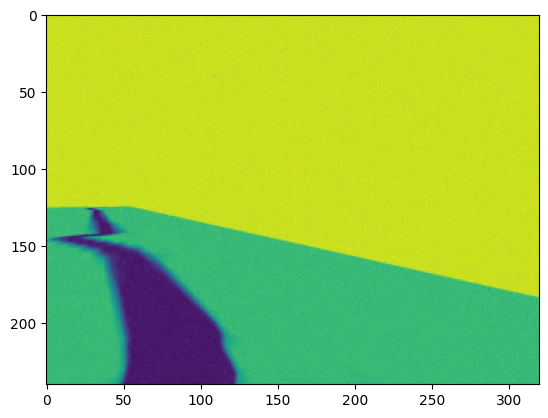

In [23]:
plt.imshow(red)

In [24]:
print(red[-1, :])

[140 136 135 133 137 136 137 139 135 135 135 135 135 135 136 135 135 136
 137 137 135 136 137 139 135 135 135 135 134 136 136 135 135 135 136 135
 136 135 133 132 135 128 127 126 122 119 120 111  90  65  45  35  33  34
  32  32  34  34  32  36  35  32  34  39  36  35  34  30  32  35  35  35
  33  33  35  32  35  34  33  33  36  35  34  34  33  33  33  36  30  36
  35  33  32  32  36  34  33  35  25  34  34  34  35  33  33  34  35  32
  34  35  35  33  36  30  33  38  39  35  36  32  33  40  59  85 112 113
 118 121 125 129 132 132 130 133 132 135 135 137 134 134 136 135 136 136
 137 135 135 139 135 135 134 135 137 135 140 135 137 137 137 137 136 134
 134 135 137 136 136 135 137 137 135 136 135 134 137 136 134 135 139 136
 137 137 136 136 134 137 137 134 139 135 136 137 139 136 136 134 134 132
 137 134 135 135 135 137 135 136 136 134 133 133 135 139 135 134 136 136
 133 137 136 139 135 136 136 135 136 136 135 135 136 136 135 134 136 135
 137 136 134 137 137 135 135 136 140 135 135 134 13

Typical ground value ~135

Typical ground value ~35

Therefor threshold set to 85

Sky value is higher and no other objects in video therefor don't need to add anything else

Highlighting bottom line of road

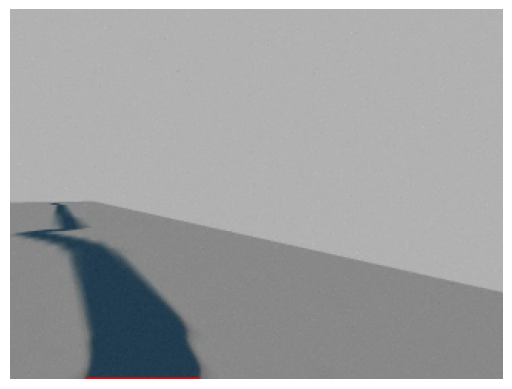

In [25]:
mask = red[-1, :] < 85

overlay = frame.copy()
overlay[-1, mask] = [0, 0, 255]

overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

plt.imshow(overlay_rgb)
plt.axis("off")
plt.show()

Finding middleo of the road and adding circle:

In [26]:
road_vals = np.where(mask)[0]

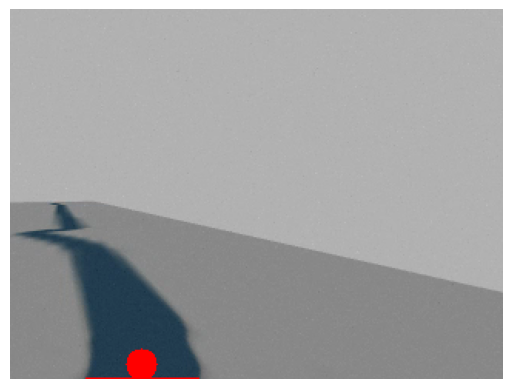

In [27]:
if len(road_vals) > 0:
    middle_road = int(np.mean(road_vals))
    y = frame.shape[0] - 10

    cv2.circle(
        overlay,
        (middle_road, y),
        10,
        (0, 0, 255),
        -1
    )

overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

plt.imshow(overlay_rgb)
plt.axis("off")
plt.show()

Full video solution

In [28]:
import cv2
import numpy as np

video_path = "/content/raw_video_feed.mp4"
output_path = "/content/output_video.mp4"

video = cv2.VideoCapture(video_path)

width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = video.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

while True:
    ret, frame = video.read()

    if not ret:
        break

    red = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    bottom_row = red[-1, :]

    mask = bottom_row < 85

    road_vals = np.where(mask)[0]

    # Draw circle only if something was detected
    if len(road_vals) > 0:
        middle_road = int(np.mean(road_vals))

        circle_y = height - 10

        cv2.circle(
            frame,
            (middle_road, circle_y),
            10,
            (0, 0, 255),
            -1
        )

    # Save this processed frame
    writer.write(frame)

video.release()
writer.release()

print("Finished processing video")

Finished processing video
